# Importación de librerías

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL

import glob
import cv2
!pip install split-folders
import splitfolders
import shutil

import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Sequential
from tensorflow.keras.models import Sequential
from sklearn.utils.class_weight import compute_class_weight

from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

Montar el drive y cargar el dataset.

In [ ]:

# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'


train_folder = os.path.join(root_dir, "train")
val_folder   = os.path.join(root_dir, "val")
test_folder  = os.path.join(root_dir, "test")

# Parámetros
batch_size= 16
img_height= 224
img_width= 224
dropout_rate = 0.5
epochs= 50
num_classes  = 6

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_folder,
  seed=123,
  image_size=(img_height, img_width),
  batch_size = batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Found 6460 files belonging to 6 classes.
Found 1382 files belonging to 6 classes.
Found 1390 files belonging to 6 classes.
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


Arquitectura

In [12]:
import tensorflow as tf

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32) # tipo int32
        y_true = tf.reshape(y_true, [-1]) # aplanar a 1D
        num_classes = tf.shape(y_pred)[-1] # número de clases desde y_pred
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes) # convertir a One-Hot
        return super().update_state(y_true_one_hot, y_pred, sample_weight) # pasar los datos al F1Score original

In [ ]:


class BaselineCNN():
    def __init__(self, input_shape, num_classes):
        # ── Augmentation (fuera del modelo, solo en train_ds) ──────────────────
        self.augment = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ], name="augmentation")

        
        inputs = tf.keras.Input(shape=input_shape)
        x = layers.Rescaling(1./255)(inputs)

        # Bloque 1
        x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.2)(x)

        # Bloque 2
        x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        # Bloque 3
        x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.3)(x)

        # Bloque 4
        x = layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.GlobalAveragePooling2D()(x)  # sin Flatten, sin 25M params

        # Clasificador
        x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.4)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)

        self.model = tf.keras.Model(inputs, outputs, name="BaselineCNN")
        self.model.summary()

    def apply_augmentation(self, train_ds):
        """Llama esto antes de train() para aplicar aug solo en train."""
        return train_ds.map(
            lambda x, y: (self.augment(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        ).prefetch(tf.data.AUTOTUNE)

    def train(self):
        lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=3e-4,
            decay_steps=404 * 50,  # total steps para 50 epochs
            alpha=1e-6             # lr mínimo al final
        )
        self.model.compile(
            optimizer=tf.keras.optimizers.AdamW(
                learning_rate=lr_schedule,
                weight_decay=1e-4
            ),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy', SparseF1Score(average='weighted', name='f1_score')]
        )

    def fit_model(self):
        labels = np.concatenate([y for x, y in train_ds], axis=0)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(labels),
            y=labels
        )
        class_weight_dict = dict(enumerate(class_weights))

        # ── Callbacks — solo EarlyStopping y Checkpoint, sin ReduceLROnPlateau
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_f1_score',
                patience=7,
                restore_best_weights=True,
                mode='max',
                verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                '/content/drive/MyDrive/best_model.keras',
                monitor='val_f1_score',
                save_best_only=True,
                mode='max',
                verbose=1
            ),
        ]

        self.history = self.model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weight_dict,
        callbacks=callbacks
    )

    def plots(self):
        acc     = self.history.history['accuracy']
        val_acc = self.history.history['val_accuracy']
        loss    = self.history.history['loss']
        val_loss= self.history.history['val_loss']

        epochs_range = range(len(acc))  # len(acc), no epochs global

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, label='Train accuracy')
        plt.plot(epochs_range, val_acc, label='Val accuracy')
        plt.legend(loc='lower right')
        plt.title('Accuracy')
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, label='Train loss')
        plt.plot(epochs_range, val_loss, label='Val loss')
        plt.legend(loc='upper right')
        plt.title('Loss')
        plt.grid(True)
        plt.tight_layout()

    def get_predictions(self, dataset):
        y_true, y_pred, images_list = [], [], []
        for images, labels in dataset:
            preds = self.model.predict(images, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(labels.numpy())
            images_list.extend(images.numpy())
        return np.array(y_true), np.array(y_pred), np.array(images_list)

    def plot_confusion_matrix(self, y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title('Confusion matrix (normalized)')
        ax.set_ylabel('True label')
        ax.set_xlabel('Predicted label')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=120)
        plt.show()

    def plot_misclassified(self, y_true, y_pred, images, class_names, n=12):
        wrong_idx = np.where(y_true != y_pred)[0]
        print(f'Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}')
        show = wrong_idx[:n]
        cols = 4
        rows = int(np.ceil(len(show) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
        axes = axes.flatten()
        for i, idx in enumerate(show):
            img = images[idx].astype('uint8')
            axes[i].imshow(img)
            axes[i].set_title(
                f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
                color='red', fontsize=10)
            axes[i].axis('off')
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
        plt.suptitle('Imágenes mal clasificadas', fontsize=13)
        plt.tight_layout()
        plt.savefig('misclassified.png', dpi=120)
        plt.show()

    def evaluate(self):
        print("\n── Evaluación en Test ──")
        results = self.model.evaluate(test_ds, verbose=1)
        for name, val in zip(self.model.metrics_names, results):
            print(f"  {name}: {val:.4f}")

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 619,174 (2.36 MB)

 Trainable params: 617,510 (2.36 MB)

 Non-trainable params: 1,664 (6.50 KB)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2059 - f1_score: 0.2104 - loss: 2.0830
Epoch 1: val_f1_score improved from None to 0.06115, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 86s 172ms/step - accuracy: 0.2288 - f1_score: 0.2321 - loss: 1.9743 - val_accuracy: 0.1795 - val_f1_score: 0.0612 - val_loss: 1.9491
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2838 - f1_score: 0.2847 - loss: 1.8200
Epoch 2: val_f1_score improved from 0.06115 to 0.21537, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 56s 139ms/step - accuracy: 0.3034 - f1_score: 0.3045 - loss: 1.7895 - val_accuracy: 0.2663 - val_f1_score: 0.2154 - val_loss: 1.8284
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3658 - f1_score: 0.3663

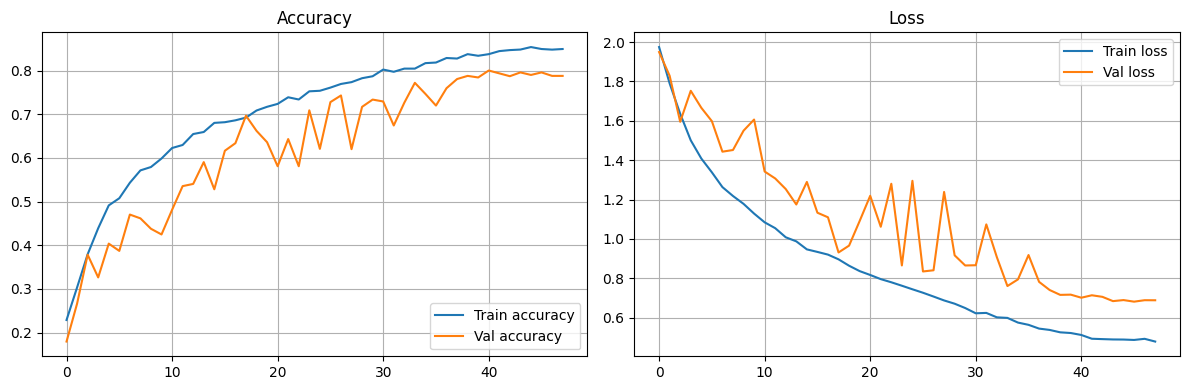

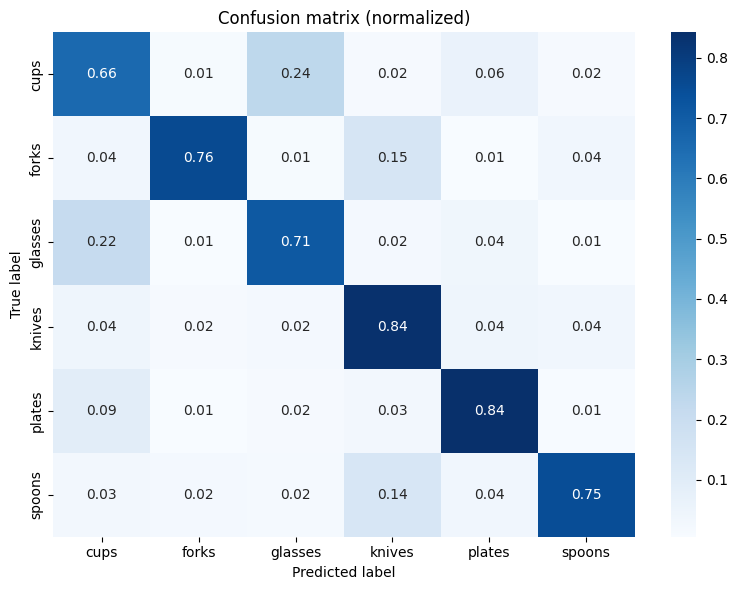

Total mal clasificadas: 335 / 1390


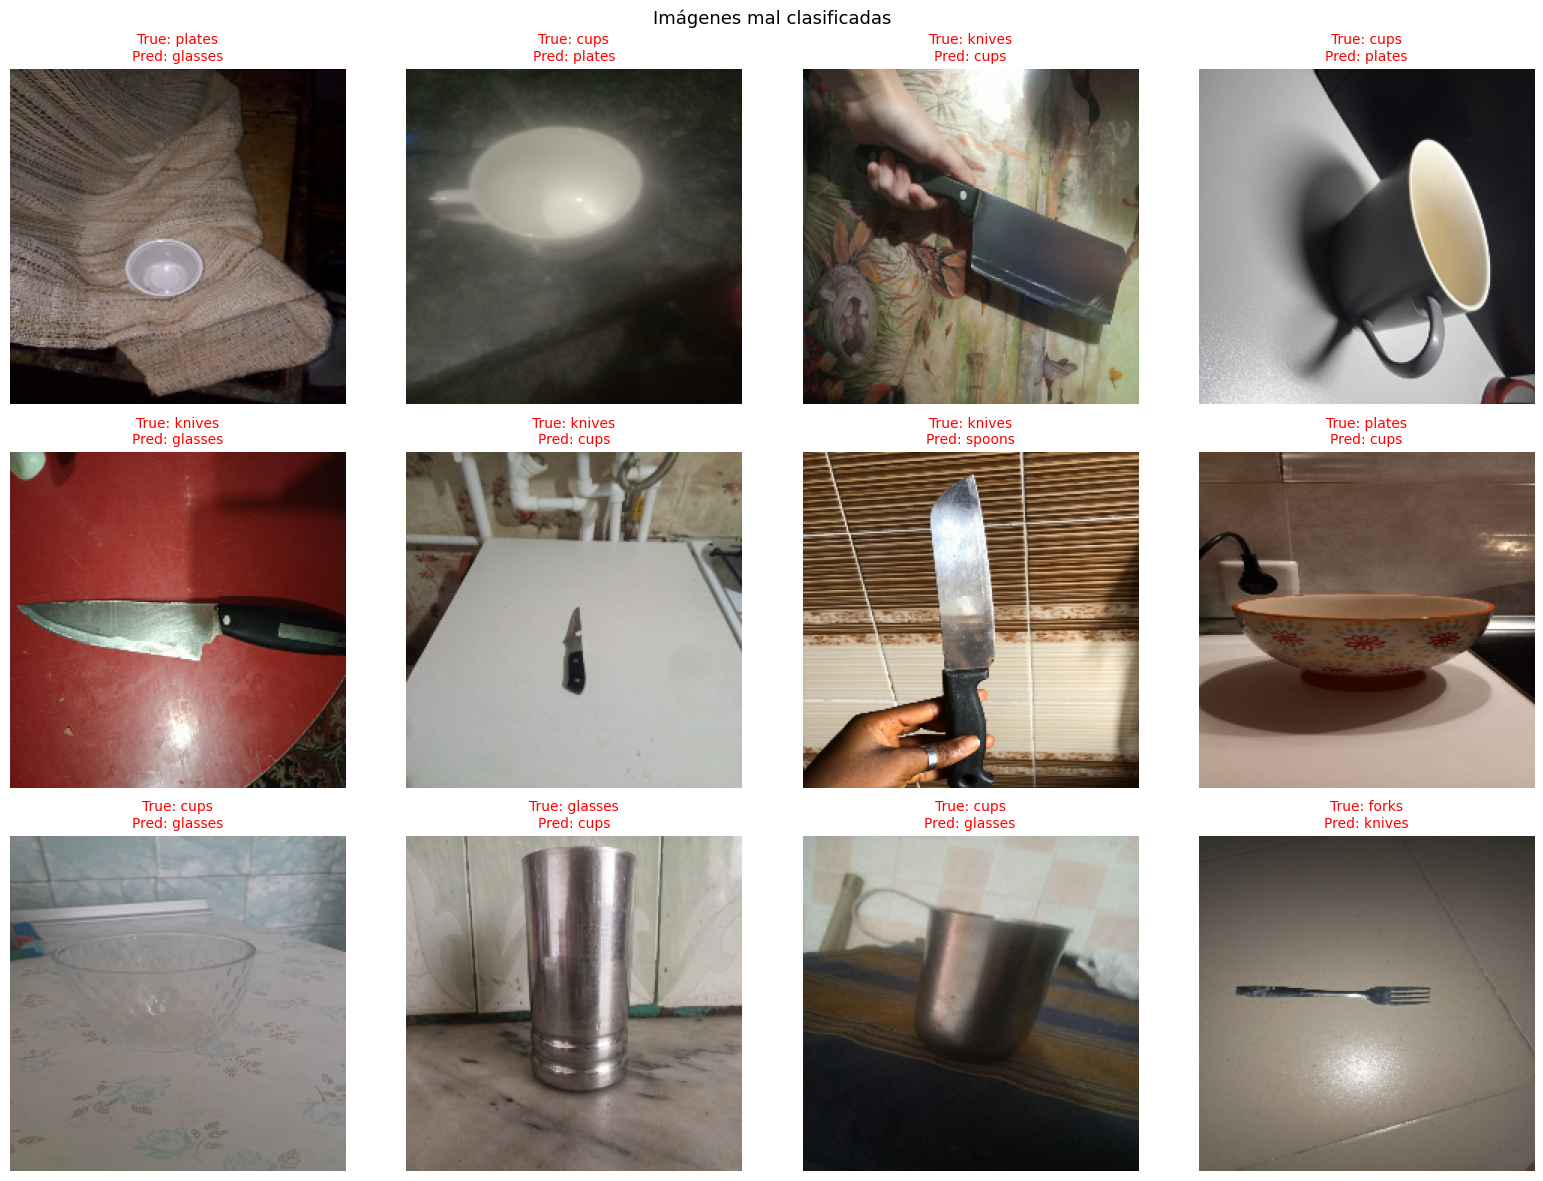

In [16]:
if __name__ == '__main__':
    model = BaselineCNN(input_shape=(224, 224, 3), num_classes=num_classes)
    model.train()
    model.fit_model()
    model.plots()
    model.evaluate()
    y_true, y_pred, images_arr = model.get_predictions(test_ds)
    model.plot_confusion_matrix(y_true, y_pred, class_names)
    model.plot_misclassified(y_true, y_pred, images_arr, class_names, n=12)